In [ ]:
!pip install -q unsloth
!pip install -q transformers
!pip install -q datasets
!pip install -q evaluate
!pip install -q bert-score
!pip install -q rouge-score
!pip install -q openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 28.3 MB/s eta 0:00:00


In [ ]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import Dataset

from sklearn.model_selection import train_test_split

import evaluate

from unsloth import FastLanguageModel

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===============================
# CONFIGURACIÓN
# ===============================

SEED = 42

MAX_SEQ_LENGTH = 8192

MODEL_PATH = "/content/drive/MyDrive/informes_legales_ai2/modelo_fusionado2"

DATASET_PATH = "/content/drive/MyDrive/TESIS/dataset/legal_dataset_final.json"

RESULTADOS_PATH = "/content/drive/MyDrive/TESIS/resultados"

os.makedirs(RESULTADOS_PATH, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(DEVICE)

cuda


In [ ]:
print("Cargando modelo...")

model, tokenizer = FastLanguageModel.from_pretrained(

    model_name=MODEL_PATH,

    max_seq_length=MAX_SEQ_LENGTH,

    dtype=None,

    load_in_4bit=True,

)

FastLanguageModel.for_inference(model)

print("Modelo cargado correctamente.")

Cargando modelo...
==((====))==  Unsloth 2026.8.8: Fast Llama patching. Transformers: 4.55.4.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Modelo cargado correctamente.


In [ ]:
print("Cargando dataset...")

with open(DATASET_PATH,"r",encoding="utf-8") as f:

    data=json.load(f)

print(f"Total de expedientes : {len(data)}")

Cargando dataset...
Total de expedientes : 453


In [ ]:
train_data, val_data = train_test_split(

    data,

    test_size=0.20,

    random_state=SEED,

    shuffle=True

)

In [ ]:
print("Entrenamiento :",len(train_data))

print("Validación :",len(val_data))

Entrenamiento : 362
Validación : 91


In [ ]:
val_dataset = Dataset.from_list(val_data)

print(val_dataset)

Dataset({
    features: ['output', 'input', 'instruction'],
    num_rows: 91
})


In [ ]:
ejemplo = val_dataset[0]

print("========== INSTRUCTION ==========")
print(ejemplo["instruction"])

print("\n========== INPUT ==========")
print(ejemplo["input"][:1000])

print("\n========== OUTPUT ==========")
print(ejemplo["output"][:1000])

========== INSTRUCTION ==========
OPINIÓN LEGAL SOBRE REAPERTURA DE LIBRO DE ACTAS DE OPAVEC.

========== INPUT ==========


========== OUTPUT ==========
Mediante el presente documento me dirijo a su Despacho a efecto de emitir pronunciamiento legal respecto a la solicitud de reapertura de libro de actas de la Oficina de Participación Vecinal y Comunal (en adelante OPAVEC), opinión que se emite conforme a los siguientes fundamentos:
I. ANTECEDENTES:
1.1. Mediante Informe N° 28-OPAVEC/EHB-MPC-2022 de fecha 22 de marzo de 2022 (Proveído N° 2238-GM-MPC-2022) el jefe de OPAVEC solicita opinión legal para reapertura del libro de acta sobre las elecciones de Juez de Paz con la finalidad de levantar las observaciones sometidas en el proceso de elecciones antes citado.
II. BASE LEGAL:
• Constitución Política del Perú.
• Ley N° 27972, Ley Orgánica de Municipalidades.
• Ley N° 27783, Ley de Bases de la Descentralización.
• Ley N° 27444, Ley del Procedimiento Administrativo General.
• Ley N° 2982

In [ ]:
bleu_metric = evaluate.load("bleu")

rouge_metric = evaluate.load("rouge")

bertscore_metric = evaluate.load("bertscore")

In [ ]:
resultados=[]

predicciones=[]

referencias=[]

In [ ]:
# ==========================================================
# FUNCIÓN DE INFERENCIA
# ==========================================================

def generar_respuesta(instruction, input_text):

    # Construir el mismo prompt utilizado durante el entrenamiento
    prompt = f"""### Instruction:
{instruction}

### Input:
{input_text}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH
    ).to(DEVICE)

    # Medir tiempo
    inicio = time.perf_counter()

    with torch.no_grad():

        outputs = model.generate(

            **inputs,

            max_new_tokens=2048,

            do_sample=False,

            temperature=0.0,

            use_cache=True,

            pad_token_id=tokenizer.eos_token_id,

            eos_token_id=tokenizer.eos_token_id,
        )

    fin = time.perf_counter()

    tiempo = fin - inicio

    respuesta = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    # Extraer únicamente la respuesta del modelo
    if "### Response:" in respuesta:
        respuesta = respuesta.split("### Response:")[-1].strip()

    # Tokens generados
    input_tokens = inputs["input_ids"].shape[1]
    output_tokens = outputs.shape[1]
    generated_tokens = output_tokens - input_tokens

    return respuesta, tiempo, generated_tokens

In [ ]:
# ==========================================================
# EVALUACIÓN DEL CONJUNTO DE VALIDACIÓN
# ==========================================================

from tqdm import tqdm

resultados = []

predicciones = []

referencias = []

print(f"Evaluando {len(val_dataset)} expedientes...\n")

for i, ejemplo in enumerate(tqdm(val_dataset), start=1):

    instruction = ejemplo["instruction"]

    input_text = ejemplo["input"]

    referencia = ejemplo["output"]

    # Generar respuesta
    respuesta, tiempo, tokens = generar_respuesta(
        instruction,
        input_text
    )

    predicciones.append(respuesta)

    referencias.append(referencia)

    resultados.append({

        "Expediente": i,

        "Instruction": instruction,

        "Referencia": referencia,

        "Prediccion": respuesta,

        "Tiempo (s)": tiempo,

        "Tokens": tokens

    })

print("Evaluación finalizada.")

Evaluando 91 expedientes...



100%|██████████| 91/91 [2:32:29<00:00, 100.55s/it]

Evaluación finalizada.


In [ ]:
# ==========================================================
# CREAR DATAFRAME DE RESULTADOS
# ==========================================================

df_resultados = pd.DataFrame(resultados)

print(df_resultados.head())

print(f"\nTotal de expedientes evaluados: {len(df_resultados)}")

   Expediente                                        Instruction  \
0           1  OPINIÓN LEGAL SOBRE REAPERTURA DE LIBRO DE ACT...   
1           2  OLICITUD DE RESOLUCION DE CONTRATO - ORDEN DE ...   
2           3  VACACIONES TRUNCAS - D. Leg. N° 1057 - CAS CON...   
3           4  OPINIÓN LEGAL SOBRE SOLICITUD DE EXONERACIÓN D...   
4           5  PERMISO SINDICAL DE TRABAJADORES AGREMIADOS EN...   

                                          Referencia  \
0  Mediante el presente documento me dirijo a su ...   
1  ediante el presente me dirijo a Ud. en atenció...   
2  Mediante el presente me dirijo a Ud. en atenci...   
3  Mediante el presente documento me dirijo a su ...   
4  Mediante el presente documento me dirijo a su ...   

                                          Prediccion  Tiempo (s)  Tokens  
0  Mediante el presente me dirijo a Ud. en atenci...  127.016610    2048  
1  INFORME N°008-2022-MPC/OGA/ULSA/PERU COMPRAS\n...  124.175657    2048  
2  {'message': 'OK', 'data': 

In [ ]:
# ==========================================================
# BLEU
# ==========================================================

bleu_metric = evaluate.load("bleu")

bleu = bleu_metric.compute(
    predictions=predicciones,
    references=[[r] for r in referencias]
)

BLEU = bleu["bleu"]

print(f"BLEU : {BLEU:.4f}")

BLEU : 0.0917


In [ ]:
# ==========================================================
# ROUGE
# ==========================================================

rouge_metric = evaluate.load("rouge")

rouge = rouge_metric.compute(
    predictions=predicciones,
    references=referencias
)

ROUGE1 = rouge["rouge1"]
ROUGE2 = rouge["rouge2"]
ROUGEL = rouge["rougeL"]

print(f"ROUGE-1 : {ROUGE1:.4f}")
print(f"ROUGE-2 : {ROUGE2:.4f}")
print(f"ROUGE-L : {ROUGEL:.4f}")

ROUGE-1 : 0.2948
ROUGE-2 : 0.1344
ROUGE-L : 0.1745


In [ ]:
# ==========================================================
# BERTScore
# ==========================================================

bertscore_metric = evaluate.load("bertscore")

bert = bertscore_metric.compute(

    predictions=predicciones,

    references=referencias,

    lang="es"

)

BERT_PRECISION = np.mean(bert["precision"])
BERT_RECALL = np.mean(bert["recall"])
BERT_F1 = np.mean(bert["f1"])

print(f"BERT Precision : {BERT_PRECISION:.4f}")
print(f"BERT Recall    : {BERT_RECALL:.4f}")
print(f"BERT F1        : {BERT_F1:.4f}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

BERT Precision : 0.7036
BERT Recall    : 0.6700
BERT F1        : 0.6858


In [ ]:
# ==========================================================
# EXACT MATCH
# ==========================================================

coincidencias = 0

for pred, ref in zip(predicciones, referencias):

    if pred.strip() == ref.strip():

        coincidencias += 1

EXACT_MATCH = coincidencias / len(predicciones)

print(f"Exact Match : {EXACT_MATCH:.4f}")

Exact Match : 0.0000


In [ ]:
# ==========================================================
# TIEMPO Y TOKENS
# ==========================================================

TIEMPO_PROMEDIO = df_resultados["Tiempo (s)"].mean()

TOKENS_PROMEDIO = df_resultados["Tokens"].mean()

print(f"Tiempo promedio : {TIEMPO_PROMEDIO:.2f} segundos")

print(f"Tokens promedio : {TOKENS_PROMEDIO:.0f}")

Tiempo promedio : 100.54 segundos
Tokens promedio : 1674


In [ ]:
# ==========================================================
# RESUMEN GENERAL
# ==========================================================

resumen = pd.DataFrame({

    "Métrica":[

        "BLEU",

        "ROUGE-1",

        "ROUGE-2",

        "ROUGE-L",

        "BERT Precision",

        "BERT Recall",

        "BERT F1",

        "Exact Match",

        "Tiempo Promedio (s)",

        "Tokens Promedio"

    ],

    "Valor":[

        BLEU,

        ROUGE1,

        ROUGE2,

        ROUGEL,

        BERT_PRECISION,

        BERT_RECALL,

        BERT_F1,

        EXACT_MATCH,

        TIEMPO_PROMEDIO,

        TOKENS_PROMEDIO

    ]

})

display(resumen)

,Métrica,Valor
0,BLEU,0.091652
1,ROUGE-1,0.294756
2,ROUGE-2,0.134396
3,ROUGE-L,0.174469
4,BERT Precision,0.703614
5,BERT Recall,0.670019
6,BERT F1,0.685780
7,Exact Match,0.000000
8,Tiempo Promedio (s),100.542491
9,Tokens Promedio,1673.582418


In [ ]:
import re

# Caracteres ilegales para Excel
ILLEGAL_CHARACTERS_RE = re.compile(
    r'[\x00-\x08\x0B\x0C\x0E-\x1F]'
)

def limpiar_excel(valor):
    """
    Elimina caracteres ilegales para OpenPyXL.
    """
    if isinstance(valor, str):
        return ILLEGAL_CHARACTERS_RE.sub("", valor)
    return valor
df_resultados = df_resultados.apply(
    lambda col: col.map(limpiar_excel)
)

resumen = resumen.apply(
    lambda col: col.map(limpiar_excel)
)

In [ ]:
# ==========================================================
# EXPORTAR RESULTADOS
# ==========================================================
from google.colab import drive
drive.mount('/content/drive')
df_resultados.to_excel(
    os.path.join(RESULTADOS_PATH,"Resultados_Detallados.xlsx"),
    index=False
)

df_resultados.to_csv(
    os.path.join(RESULTADOS_PATH,"Resultados_Detallados.csv"),
    index=False,
    encoding="utf-8-sig"
)

resumen.to_excel(
    os.path.join(RESULTADOS_PATH,"Resumen_Metricas.xlsx"),
    index=False
)

print("Archivos exportados correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos exportados correctamente.


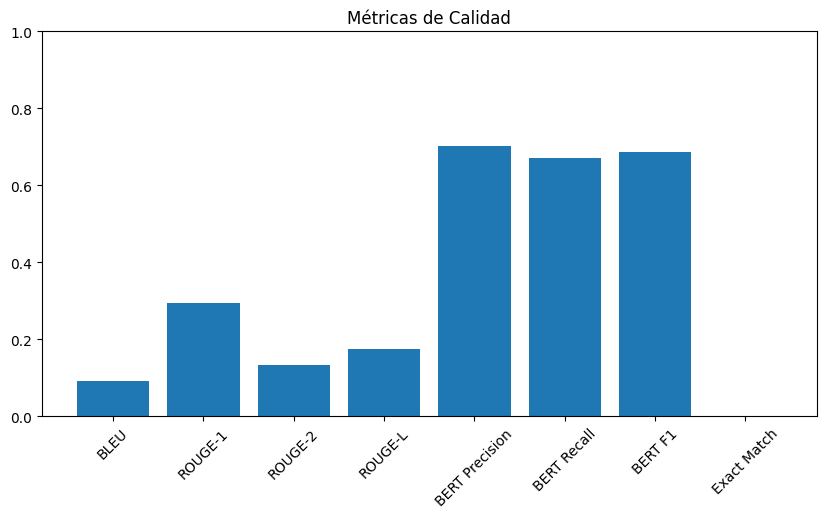

In [ ]:
metricas_texto = resumen[
    resumen["Métrica"].isin([
        "BLEU",
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BERT Precision",
        "BERT Recall",
        "BERT F1",
        "Exact Match"
    ])
]

plt.figure(figsize=(10,5))

plt.bar(metricas_texto["Métrica"], metricas_texto["Valor"])

plt.ylim(0,1)

plt.xticks(rotation=45)

plt.title("Métricas de Calidad")

plt.show()

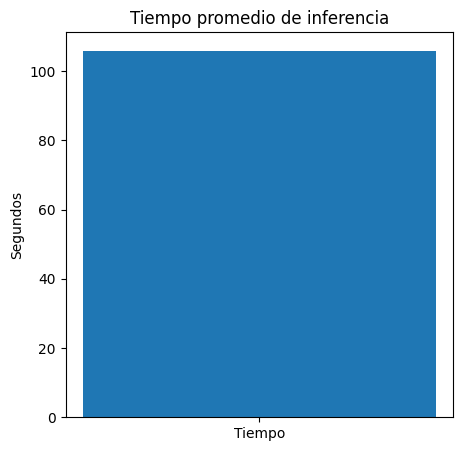

In [ ]:
plt.figure(figsize=(5,5))

plt.bar(
    ["Tiempo"],
    [TIEMPO_PROMEDIO]
)

plt.ylabel("Segundos")

plt.title("Tiempo promedio de inferencia Mistral")

plt.show()

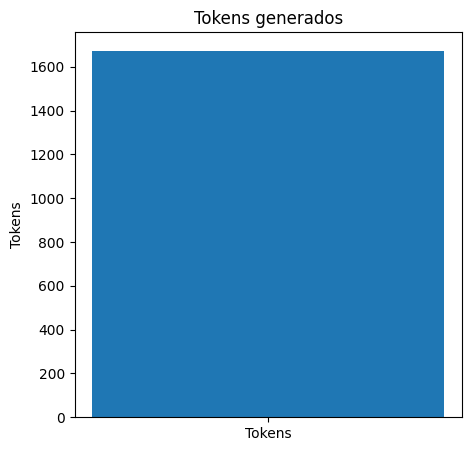

In [ ]:
plt.figure(figsize=(5,5))

plt.bar(
    ["Tokens"],
    [TOKENS_PROMEDIO]
)

plt.ylabel("Tokens")

plt.title("Tokens generados Mistral")

plt.show()